<a href="https://colab.research.google.com/github/Geethasaikrishna/udlbook/blob/experiments/Notebooks/Chap02/2_1_Supervised_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notebook 2.1 Supervised Learning

The purpose of this notebook is to explore the linear regression model discussed in Chapter 2 of the book.

Work through the cells below, running each cell in turn. In various places you will see the words "TODO". Follow the instructions at these places and write code to complete the functions. There are also questions interspersed in the text.

Contact me at udlbookmail@gmail.com if you find any mistakes or have any suggestions.

In [1]:
# Math library
import numpy as np
# Plotting library
import matplotlib.pyplot as plt

In [2]:
# Create some input / output data
x = np.array([0.03, 0.19, 0.34, 0.46, 0.78, 0.81, 1.08, 1.18, 1.39, 1.60, 1.65, 1.90])
y = np.array([0.67, 0.85, 1.05, 1.0, 1.40, 1.5, 1.3, 1.54, 1.55, 1.68, 1.73, 1.6 ])

print(x)
print(y)

[0.03 0.19 0.34 0.46 0.78 0.81 1.08 1.18 1.39 1.6  1.65 1.9 ]
[0.67 0.85 1.05 1.   1.4  1.5  1.3  1.54 1.55 1.68 1.73 1.6 ]


In [6]:
# Define 1D linear regression model
def f(x, phi0, phi1):
  # TODO :  Replace this line with the linear regression model (eq 2.4)
  y = phi0+ phi1*x

  return y

In [7]:
# Function to help plot the data
def plot(x, y, phi0, phi1):
    fig,ax = plt.subplots()
    ax.scatter(x,y)
    plt.xlim([0,2.0])
    plt.ylim([0,2.0])
    ax.set_xlabel('Input, $x$')
    ax.set_ylabel('Output, $y$')
    # Draw line
    x_line = np.arange(0,2,0.01)
    y_line = f(x_line, phi0, phi1)
    plt.plot(x_line, y_line,'b-',lw=2)

    plt.show()

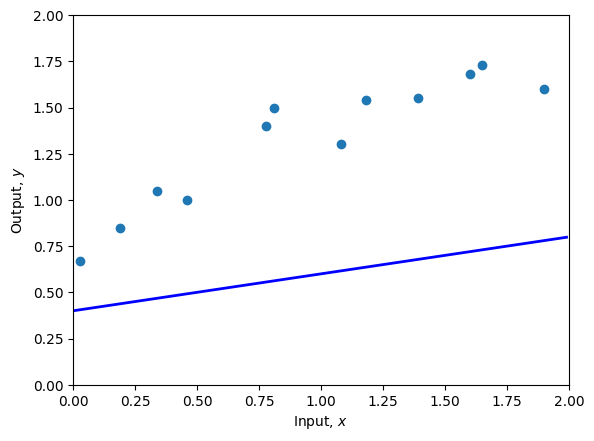

In [19]:
# Set the intercept and slope as in figure 2.2b
phi0 = 0.4 ; phi1 = 0.2
# Plot the data and the model
plot(x,y,phi0,phi1)

In [20]:
# Function to calculate the loss
def compute_loss(x,y,phi0,phi1):

  # TODO Replace this line with the loss calculation (equation 2.5)
  loss = 0
  for i in range(0,len(x)):
    loss = loss + (y[i]-f(x[i],phi0,phi1))**2




  return loss

In [21]:
# Compute the loss for our current model
loss = compute_loss(x,y,phi0,phi1)
print(f'Your Loss = {loss:3.2f}, Ground truth =7.07')

Your Loss = 7.07, Ground truth =7.07


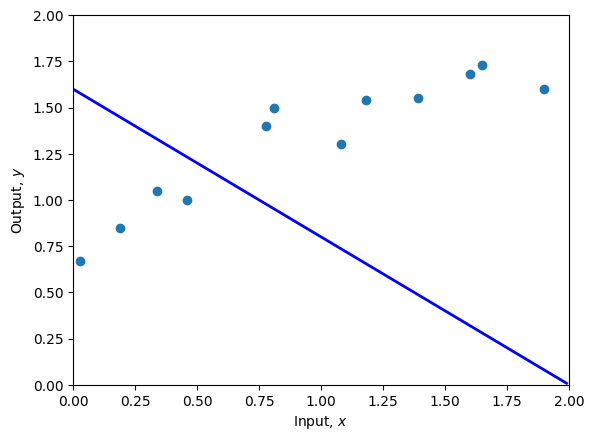

Your Loss = 10.28, Ground truth =10.28


In [23]:
# Set the intercept and slope as in figure 2.2c
phi0 = 1.60 ; phi1 =-0.8
# Plot the data and the model
plot(x,y,phi0,phi1)
loss = compute_loss(x,y,phi0,phi1)
print(f'Your Loss = {loss:3.2f}, Ground truth =10.28')

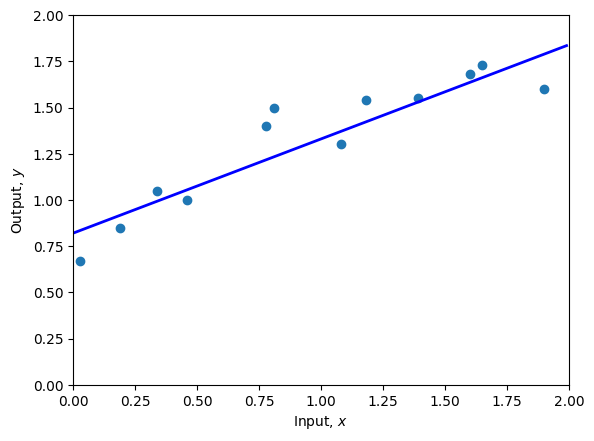

Your Loss = 0.20


In [41]:
# TODO -- Change the parameters manually to fit the model
# First fix phi1 and try changing phi0 until you can't make the loss go down any more
# Then fix phi0 and try changing phi1 until you can't make the loss go down any more
# Repeat this process until you find a set of parameters that fit the model as in figure 2.2d
# You can either do this by hand, or if you want to get fancy, write code to descent automatically in this way
# Start at these values:
phi0 = 0.82 ; phi1 =0.51

plot(x,y,phi0,phi1)
print(f'Your Loss = {compute_loss(x,y,phi0,phi1):3.2f}')

# Visualizing the loss function

The above process is equivalent to descending coordinate wise on the loss function<br>

Now let's plot that function

In [ ]:
np.ndenumerate()

In [65]:
# Make a 2D grid of possible phi0 and phi1 values
phi0_mesh, phi1_mesh = np.meshgrid(np.arange(0.0,2.0,0.02), np.arange(-1.0,1.0,0.02))

# Make a 2D array for the losses
all_losses = np.zeros_like(phi1_mesh)
# Run through each 2D combination of phi0, phi1 and compute loss
for indices,temp in np.ndenumerate(phi1_mesh):
    all_losses[indices] = compute_loss(x,y, phi0_mesh[indices], phi1_mesh[indices])


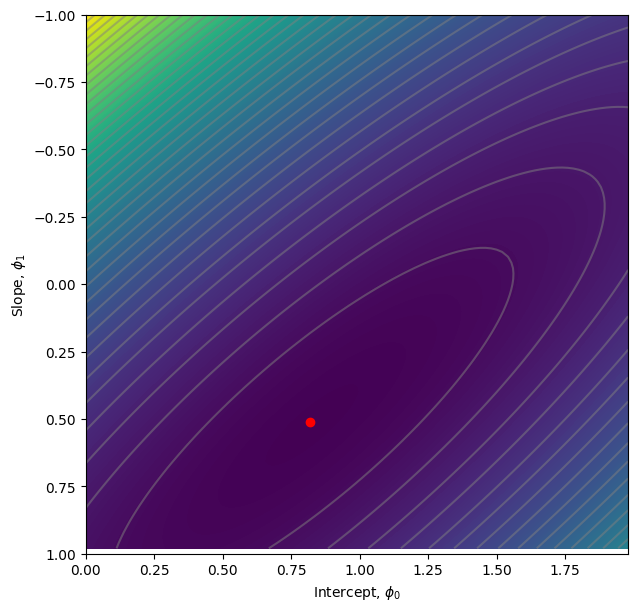

In [66]:
# Plot the loss function as a heatmap
fig = plt.figure()
ax = plt.axes()
fig.set_size_inches(7,7)
levels = 256
ax.contourf(phi0_mesh, phi1_mesh, all_losses ,levels)
levels = 40
ax.contour(phi0_mesh, phi1_mesh, all_losses ,levels, colors=['#80808080'])
ax.set_ylim([1,-1])
ax.set_xlabel(r'Intercept, $\phi_0$')
ax.set_ylabel(r'Slope, $\phi_1$')

# Plot the position of your best fitting line on the loss function
# It should be close to the minimum
ax.plot(phi0,phi1,'ro')
plt.show()

In [67]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Define an elliptical loss function
# This function will be much more sensitive to changes in phi0 than phi1
def elliptical_loss(phi0, phi1):
    # A simple quadratic function where phi0 is scaled more than phi1
    # The minimum is at (0,0)
    return 10 * phi0**2 + 1 * phi1**2

# 2. Define the gradients of the loss function
# dL/d(phi0) and dL/d(phi1)
def compute_gradients_elliptical(phi0, phi1):
    grad_phi0 = 2 * 10 * phi0  # Derivative with respect to phi0
    grad_phi1 = 2 * 1 * phi1   # Derivative with respect to phi1
    return grad_phi0, grad_phi1

# 3. Implement Gradient Descent
def gradient_descent_elliptical(initial_phi0, initial_phi1, learning_rate, num_iterations):
    phi0 = initial_phi0
    phi1 = initial_phi1

    phi0_history = [phi0]
    phi1_history = [phi1]
    loss_history = [elliptical_loss(phi0, phi1)]

    for i in range(num_iterations):
        grad_phi0, grad_phi1 = compute_gradients_elliptical(phi0, phi1)

        phi0 -= learning_rate * grad_phi0
        phi1 -= learning_rate * grad_phi1

        phi0_history.append(phi0)
        phi1_history.append(phi1)
        loss_history.append(elliptical_loss(phi0, phi1))

    return np.array(phi0_history), np.array(phi1_history), np.array(loss_history)

# 4. Visualize the loss surface and GD path

def plot_gd_path(phi0_hist, phi1_hist, loss_hist, learning_rate_str):
    # Create a grid for the contour plot
    phi0_mesh, phi1_mesh = np.meshgrid(np.linspace(-1.5, 1.5, 100), np.linspace(-1.5, 1.5, 100))
    loss_surface = elliptical_loss(phi0_mesh, phi1_mesh)

    plt.figure(figsize=(10, 7))
    plt.contour(phi0_mesh, phi1_mesh, loss_surface, levels=np.logspace(-1, 2, 20), cmap='viridis')
    plt.colorbar(label='Loss Value')
    plt.xlabel('$\phi_0$ (Steeper Direction)')
    plt.ylabel('$\phi_1$ (Flatter Direction)')
    plt.title(f'Gradient Descent on Elliptical Loss Surface (LR={learning_rate_str})')

    plt.plot(phi0_hist, phi1_hist, 'ro-', markersize=4, label='GD Path')
    plt.plot(phi0_hist[0], phi1_hist[0], 'gx', markersize=10, label='Start')
    plt.plot(0, 0, 'y*', markersize=10, label='Minimum')
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(10, 4))
    plt.plot(loss_hist)
    plt.xlabel('Iteration')
    plt.ylabel('Loss')
    plt.title(f'Loss over Iterations (LR={learning_rate_str})')
    plt.grid(True)
    plt.show()

<>:49: SyntaxWarning: invalid escape sequence '\p'
<>:50: SyntaxWarning: invalid escape sequence '\p'
<>:49: SyntaxWarning: invalid escape sequence '\p'
<>:50: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipython-input-2386540637.py:49: SyntaxWarning: invalid escape sequence '\p'
  plt.xlabel('$\phi_0$ (Steeper Direction)')
/tmp/ipython-input-2386540637.py:50: SyntaxWarning: invalid escape sequence '\p'
  plt.ylabel('$\phi_1$ (Flatter Direction)')


### Scenario 1: Learning Rate is too high for the steep direction ($\phi_0$)

Here, the learning rate is chosen to be reasonably effective for the flatter $\phi_1$ direction, but it's too aggressive for $\phi_0$. Observe the oscillations along the $\phi_0$ axis.

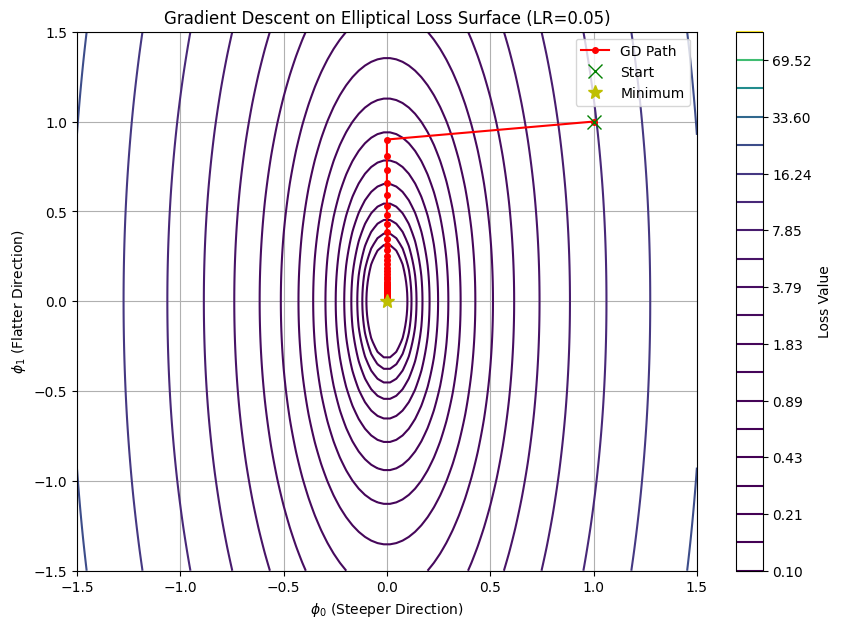

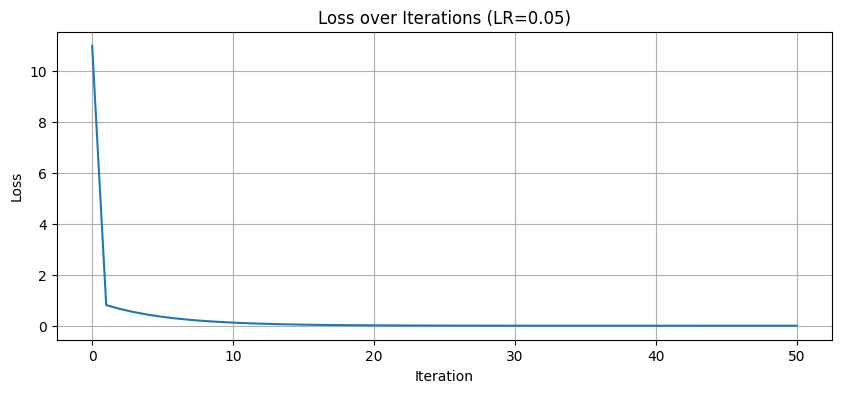

In [68]:
initial_phi0, initial_phi1 = 1.0, 1.0
learning_rate_high = 0.05 # This will be too high for phi0
num_iterations = 50

phi0_hist_high, phi1_hist_high, loss_hist_high = gradient_descent_elliptical(
    initial_phi0, initial_phi1, learning_rate_high, num_iterations
)

plot_gd_path(phi0_hist_high, phi1_hist_high, loss_hist_high, str(learning_rate_high))

### Scenario 2: Learning Rate is too low for the flat direction ($\phi_1$)

Here, the learning rate is chosen to be safe for the steep $\phi_0$ direction, but it's now too conservative for $\phi_1$. Observe how slowly it converges along the $\phi_1$ axis.

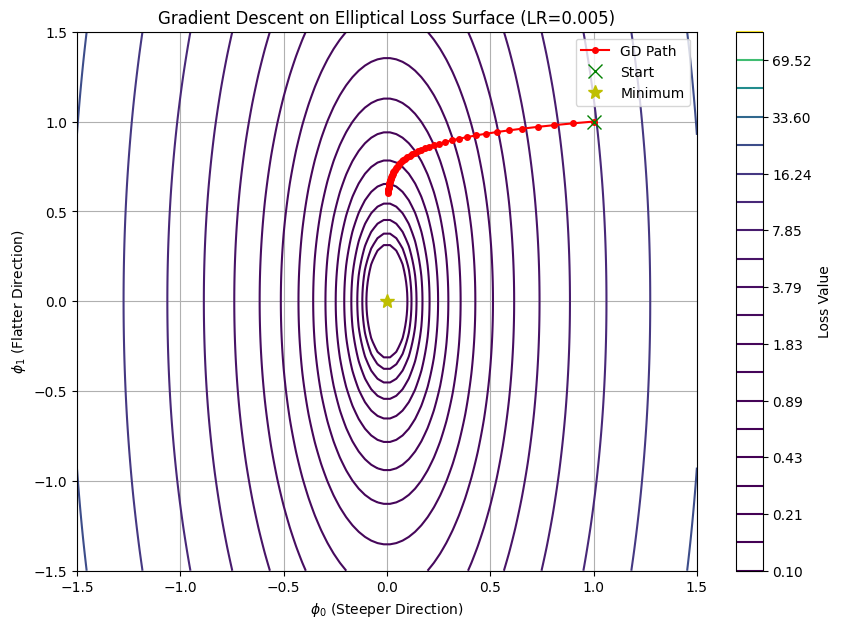

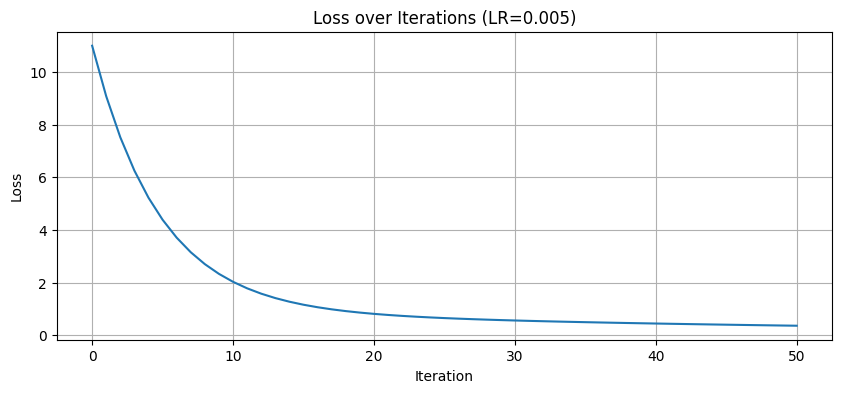

In [69]:
initial_phi0, initial_phi1 = 1.0, 1.0
learning_rate_low = 0.005 # This will be too low for phi1
num_iterations = 50

phi0_hist_low, phi1_hist_low, loss_hist_low = gradient_descent_elliptical(
    initial_phi0, initial_phi1, learning_rate_low, num_iterations
)

plot_gd_path(phi0_hist_low, phi1_hist_low, loss_hist_low, str(learning_rate_low))